In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import SparkSession, DataFrame
from pyspark.ml.feature import Imputer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# setup the configuration


In [2]:
# Local run: no MinIO/S3 needed since we're reading/writing local parquet files.
# (Keep the s3a config block commented out for when you move this back to the cluster.)
spark = (
    SparkSession.builder.appName("clean_dataset")
    .master("local[*]")
    # .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
    # .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
    # .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123")
    # .config("spark.hadoop.fs.s3a.path.style.access", "true")
    # .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/09 09:03:01 WARN Utils: Your hostname, Speranz, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/07/09 09:03:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/09 09:03:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
IMPUTER_INPUT_COLS = ["anciennete_digitale_jours", "recence_gab_jours"]
IMPUTER_OUTPUT_COLS = ["anciennete_digitale_jours_imp", "recence_gab_jours_imp"]

# Local run: save the fitted Imputer model to a local folder instead of s3a://...
# (this was the cause of the crash: hadoop-aws jar isn't installed, so s3a:// paths fail)
IMPUTER_MODEL_PATH = "./models/imputer_anciennete_recence"


In [4]:
df = spark.read.parquet("part-00000.parquet")
df.show(100, truncate=False)


26/07/09 09:04:05 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------+------+-------+------+----+-------------+----------+-------------------+----+--------+--------------+-------------+---------------+---------------+----------+-----------------+-----------+---------+-----------------------+-----------------------+-------------------+---------+----------+----------------------+------------------+------------------+------------------+-----------------+-----------------+-----------------+--------------------+----------------------+-----------+----------------------+---------------------+--------------------+-------------------+----------------------+
|RADICAL|BANQUE|AGENCE|GENERIC|PLURAL|CCLE|DATE_OF_BIRTH|CODE_VILLE|LIBELLE_VILLE      |BPR |GENDER  |MARITAL_STATUS|NOMBRE_ENFANT|CUSTOMER_RATING|TAILLE_ENTREPRI|label_code|label_nom        |pack_actuel|pack_etat|digital_date_activation|digital_toujours_abonne|solde_moyen        |solde_min|solde_max |nb_mois_observes_solde|depot_moyen       |flux_cred_moyen   |flux_cred_total   |nb_mois_avec_f

# clean Data

In [5]:
df = df.withColumn(
    "GENDER",
    F.when(F.col("GENDER") == "FÃ©minin", "Féminin")
     .when(F.col("GENDER") == "Masculin", "Masculin")
     .otherwise(None)
)

In [6]:
for i, col in enumerate(df.columns):
    print(f"col {i}: {col} =>", df.filter(F.col(col).isNull()).count())


col 0: RADICAL => 0
col 1: BANQUE => 0
col 2: AGENCE => 0
col 3: GENERIC => 0
col 4: PLURAL => 0
col 5: CCLE => 0
col 6: DATE_OF_BIRTH => 0
col 7: CODE_VILLE => 0
col 8: LIBELLE_VILLE => 155
col 9: BPR => 2
col 10: GENDER => 1
col 11: MARITAL_STATUS => 0
col 12: NOMBRE_ENFANT => 267
col 13: CUSTOMER_RATING => 0
col 14: TAILLE_ENTREPRI => 4140
col 15: label_code => 0
col 16: label_nom => 0
col 17: pack_actuel => 987
col 18: pack_etat => 987
col 19: digital_date_activation => 1385
col 20: digital_toujours_abonne => 0
col 21: solde_moyen => 0
col 22: solde_min => 0
col 23: solde_max => 0
col 24: nb_mois_observes_solde => 0
col 25: depot_moyen => 605
col 26: flux_cred_moyen => 0
col 27: flux_cred_total => 0
col 28: nb_mois_avec_flux => 0
col 29: nb_operations_gab => 0
col 30: montant_total_gab => 0
col 31: montant_moyen_gab => 1950
col 32: derniere_operation_gab => 1950
col 33: nb_retraits => 0
col 34: montant_total_retraits => 0
col 35: nb_paiements_digitaux => 0
col 36: montant_total_pay

In [7]:
df.select("LIBELLE_VILLE").distinct().show(truncate=False)

+-----------------+
|LIBELLE_VILLE    |
+-----------------+
|AIT BAHA         |
|IMZOUREN         |
|AHFIR            |
|FARKHANA         |
|BIOUGRA          |
|ZEGANGANE        |
|ET-TAOUS (TAOUZ) |
|MHAYA            |
|CHTOUKA          |
|SEBT GZOULA      |
|NADOR            |
|BOUARFA          |
|SIDI SMAIL       |
|IFRANE           |
|ASSA             |
|ERFOUD           |
|TIFLET           |
|ERRACHIDIA       |
|AL HOCEIMA       |
|AFOURAR (AFOURER)|
+-----------------+
only showing top 20 rows


In [8]:
df.groupBy("LIBELLE_VILLE").count().show()

+-----------------+-----+
|    LIBELLE_VILLE|count|
+-----------------+-----+
|         AIT BAHA|    5|
|         IMZOUREN|    2|
|            AHFIR|    6|
|         FARKHANA|    1|
|          BIOUGRA|    9|
|        ZEGANGANE|    6|
| ET-TAOUS (TAOUZ)|    2|
|            MHAYA|    2|
|          CHTOUKA|    2|
|      SEBT GZOULA|    1|
|            NADOR|   49|
|          BOUARFA|    8|
|       SIDI SMAIL|    1|
|           IFRANE|    6|
|             ASSA|    6|
|           ERFOUD|    7|
|           TIFLET|   10|
|       ERRACHIDIA|   22|
|       AL HOCEIMA|   13|
|AFOURAR (AFOURER)|    2|
+-----------------+-----+
only showing top 20 rows


# Verification des jointures


In [49]:
# Reconstruction minimale de l'union SOLDE brute, juste pour l'investigation
# (adaptez les chemins/noms de fichiers à votre arborescence réelle)

df_solde_2025 = spark.read.option("delimiter", ";").option("header", True) \
    .csv(r"\Users\Mr Tarouzi\ATT_PROD_EPARGNE_SOLDE_2025.txt")
df_solde_complement = spark.read.option("delimiter", ";").option("header", True) \
   .csv(r"\Users\Mr_Tarouzi\Downloads\ATT_PROD_EPARGNE_SOLDE_COMPLEMENT.txt")

# Union simple pour l'investigation (sans la logique de nettoyage/cast du
# pipeline complet -- juste pour voir si les doublons existent déjà au
# niveau brut)
df_solde_brut = df_solde_2025.unionByName(df_solde_complement, allowMissingColumns=True)

df_solde_brut.filter(F.col("RADICAL").isin(radicaux_suspects)) \
    .select("RADICAL", "BANQUE", "AGENCE", "GENERIC", "PLURAL", "DATE_CHARG", "SOLDEVERIF") \
    .orderBy("RADICAL", "DATE_CHARG") \
    .show(100, truncate=False)
# ---------------------------------------------------------------------------
# Investigation — nb_mois_observes_solde anormalement élevé
# Objectif : distinguer "vrai historique long" de "bug de jointure /
# doublons non filtrés lors de l'union SOLDE_2025 + SOLDE_COMPLEMENT".
# ---------------------------------------------------------------------------

# 1) Vue d'ensemble de la distribution au-delà du plausible (24 mois = 2 ans)
SEUIL_PLAUSIBLE = 24  # à ajuster si vos extraits couvrent une autre période

df_train.groupBy(
    F.when(F.col("nb_mois_observes_solde") <= SEUIL_PLAUSIBLE, "plausible (<=24)")
     .when(F.col("nb_mois_observes_solde") <= 48, "suspect (25-48)")
     .otherwise("très suspect (>48)")
     .alias("categorie")
).count().orderBy("categorie").show()

# 2) Combien de RADICAL exactement dépassent le plausible, et de combien
n_suspects = df_train.filter(F.col("nb_mois_observes_solde") > SEUIL_PLAUSIBLE).count()
print(f"Clients avec nb_mois_observes_solde > {SEUIL_PLAUSIBLE} : {n_suspects}")

df_train.filter(F.col("nb_mois_observes_solde") > SEUIL_PLAUSIBLE) \
    .select("RADICAL", "nb_mois_observes_solde") \
    .orderBy(F.desc("nb_mois_observes_solde")) \
    .show(20, truncate=False)

# 3) Le vrai test : retourner à la table SOLDE (avant agrégation) pour un
#    échantillon de ces RADICAL suspects, et regarder s'il y a plusieurs
#    lignes par (RADICAL, DATE_CHARG) -- signe d'un doublon de jointure --
#    ou bien des DATE_CHARG réellement étalées sur >24 mois distincts.
radicaux_suspects = [
    r["RADICAL"] for r in
    df_train.filter(F.col("nb_mois_observes_solde") > SEUIL_PLAUSIBLE)
            .select("RADICAL").limit(10).collect()
]
print("Échantillon de RADICAL suspects :", radicaux_suspects)

# df_solde_brut = le DataFrame issu de l'union SOLDE_2025 + SOLDE_COMPLEMENT
# AVANT agrégation (avant le groupBy qui produit nb_mois_observes_solde)
df_solde_brut.filter(F.col("RADICAL").isin(radicaux_suspects)) \
    .select("RADICAL", "BANQUE", "AGENCE", "GENERIC", "PLURAL", "DATE_CHARG", "SOLDEVERIF") \
    .orderBy("RADICAL", "DATE_CHARG") \
    .show(100, truncate=False)

# 4) Diagnostic direct : pour un même RADICAL, y a-t-il plusieurs lignes
#    avec la MÊME DATE_CHARG ? Si oui -> doublon de jointure confirmé
#    (probablement PLURAL ou GENERIC non pris en compte dans la clé
#    d'union/dédoublonnage, donc plusieurs sous-comptes comptés comme
#    des mois distincts).
df_solde_brut.filter(F.col("RADICAL").isin(radicaux_suspects)) \
    .groupBy("RADICAL", "DATE_CHARG") \
    .count() \
    .filter(F.col("count") > 1) \
    .orderBy(F.desc("count")) \
    .show(50, truncate=False)

# 5) Nombre de DATE_CHARG distinctes vs nombre de lignes brutes, par
#    RADICAL suspect -- si distinct << total, c'est bien un problème de
#    doublons (plusieurs lignes pour la même période), pas un historique
#    réellement long.
df_solde_brut.filter(F.col("RADICAL").isin(radicaux_suspects)) \
    .groupBy("RADICAL") \
    .agg(
        F.count("*").alias("nb_lignes_brutes"),
        F.countDistinct("DATE_CHARG").alias("nb_dates_distinctes"),
    ) \
    .withColumn("ratio_doublon", F.col("nb_lignes_brutes") / F.col("nb_dates_distinctes")) \
    .orderBy(F.desc("ratio_doublon")) \
    .show(20, truncate=False)

26/07/09 09:57:27 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: \Users\Mr Tarouzi\ATT_PROD_EPARGNE_SOLDE_2025.txt.
java.io.FileNotFoundException: File \Users\Mr Tarouzi\ATT_PROD_EPARGNE_SOLDE_2025.txt does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.s

Py4JJavaError: An error occurred while calling o4723.csv.
: java.io.IOException: Illegal file pattern: error parsing regexp: invalid escape sequence: `\U`
	at org.apache.hadoop.fs.GlobFilter.init(GlobFilter.java:71)
	at org.apache.hadoop.fs.GlobFilter.<init>(GlobFilter.java:50)
	at org.apache.hadoop.fs.Globber.doGlob(Globber.java:265)
	at org.apache.hadoop.fs.Globber.glob(Globber.java:202)
	at org.apache.hadoop.fs.FileSystem.globStatus(FileSystem.java:2225)
	at org.apache.spark.deploy.SparkHadoopUtil.globPath(SparkHadoopUtil.scala:240)
	at org.apache.spark.sql.execution.datasources.DataSource$.$anonfun$checkAndGlobPathIfNecessary$3(DataSource.scala:795)
	at ... run in separate thread using org.apache.spark.util.ThreadUtils ... ()
	at org.apache.spark.sql.execution.datasources.DataSource$.checkAndGlobPathIfNecessary(DataSource.scala:807)
	at org.apache.spark.sql.execution.datasources.DataSource.checkAndGlobPathIfNecessary(DataSource.scala:580)
	at org.apache.spark.sql.execution.datasour

# Script gestion des null

In [9]:
def clean_dataset(df: DataFrame) -> DataFrame:
    """
    Applique toutes les règles de nettoyage décidées pour ce projet.
    Chaque étape est commentée avec la décision métier qui la justifie
    (voir section 6.5 / 6.5bis du guide maître pour le détail).
    """

    n_avant = df.count()

    # --- 1. LIBELLE_VILLE : redondant avec CODE_VILLE (le code est fiable,
    #        0 null) -> on garde le code, on jette le libellé plutôt que
    #        d'imputer un texte qui n'apporte rien de plus au modèle ---
    if "LIBELLE_VILLE" in df.columns:
        df = df.drop("LIBELLE_VILLE")

    # --- 2. BPR / GENDER : nulls négligeables (2 et 1 lignes sur l'échantillon
    #        de référence) -> on supprime juste ces lignes, pas d'imputation ---
    subset_dropna = [c for c in ["BPR", "GENDER"] if c in df.columns]
    if subset_dropna:
        df = df.dropna(subset=subset_dropna)

    # --- 3. NOMBRE_ENFANT : null = pas d'enfant, PAS une valeur manquante
    #        à imputer par une médiane -> fillna(0) directement ---
    if "NOMBRE_ENFANT" in df.columns:
        df = df.fillna({"NOMBRE_ENFANT": 0})

    # --- 4. TAILLE_ENTREPRI : null = compte particulier (pas d'entreprise),
    #        pas une donnée manquante -> valeur catégorielle explicite.
    #        Devient un signal utile (particulier vs professionnel) au lieu
    #        d'être dropé ou imputé avec du bruit ---
    if "TAILLE_ENTREPRI" in df.columns:
        df = df.fillna({"TAILLE_ENTREPRI": "PARTICULIER"})

    # --- 4bis. pack_actuel / pack_etat : nulls groupés sur les mêmes clients
    #           (986 chacun) = clients sans pack digital, pas une vraie
    #           valeur manquante -> catégorie explicite, pas le mode ---
    pack_cols = {}
    if "pack_actuel" in df.columns:
        pack_cols["pack_actuel"] = "SANS_PACK"
    if "pack_etat" in df.columns:
        pack_cols["pack_etat"] = "SANS_ETAT"
    if pack_cols:
        df = df.fillna(pack_cols)

    # --- 5. depot_moyen / montant_moyen_gab : null = absence d'activité
    #        observée -> 0, cohérent avec le traitement déjà appliqué à
    #        flux_cred_moyen (NaN = 0, jamais une moyenne) ---
    montants_zero = [c for c in ["depot_moyen", "montant_moyen_gab"] if c in df.columns]
    if montants_zero:
        df = df.fillna({c: 0.0 for c in montants_zero})

    # --- 6. digital_date_activation : une date ne peut pas être mise à 0
    #        (serait confondu avec "activé aujourd'hui"). On dérive une
    #        ancienneté en jours + un flag explicite, puis on jette la
    #        date brute qui n'est de toute façon pas exploitable telle
    #        quelle par VectorAssembler ---
    if "digital_date_activation" in df.columns:
        df = (
            df.withColumn(
                "jamais_active_digital",
                F.when(F.col("digital_date_activation").isNull(), 1).otherwise(0),
            )
            .withColumn(
                "anciennete_digitale_jours",
                F.when(F.col("digital_date_activation").isNull(), F.lit(None))
                .otherwise(
                    F.datediff(
                        F.current_date(),
                        F.to_date("digital_date_activation", "dd/MM/yyyy"),
                    )
                ),
            )
            .drop("digital_date_activation")
        )

    # --- 7. derniere_operation_gab : même logique que #6, format datetime ---
    if "derniere_operation_gab" in df.columns:
        df = (
            df.withColumn(
                "jamais_utilise_gab",
                F.when(F.col("derniere_operation_gab").isNull(), 1).otherwise(0),
            )
            .withColumn(
                "recence_gab_jours",
                F.when(F.col("derniere_operation_gab").isNull(), F.lit(None))
                .otherwise(
                    F.datediff(
                        F.current_date(),
                        F.to_date(
                            F.col("derniere_operation_gab"), "dd/MM/yyyy HH:mm:ss"
                        ),
                    )
                ),
            )
            .drop("derniere_operation_gab")
        )

    n_apres = df.count()
    print(f"    Lignes avant : {n_avant} | après (dropna BPR/GENDER) : {n_apres}")

    return df

In [10]:
def run(path_in: str, path_out: str, label: str):
    print(f"\n{'=' * 20} NETTOYAGE : {label} {'=' * 20}")
    print(f"Lecture : {path_in}")
    df = spark.read.parquet(path_in)

    print("Nulls avant nettoyage :")
    df.select(
        [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]
    ).show(truncate=False, vertical=True)

    df_clean = clean_dataset(df)

    print("Nulls après nettoyage :")
    df_clean.select(
        [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_clean.columns]
    ).show(truncate=False, vertical=True)

    print(f"Écriture : {path_out}")
    df_clean.write.mode("overwrite").parquet(path_out)
    print(f"OK : {label} nettoyé et écrit.\n")


In [11]:
def apply_base_cleaning(path_in: str, label: str) -> DataFrame:
    print(f"\n{'=' * 20} NETTOYAGE DE BASE : {label} {'=' * 20}")
    print(f"Lecture : {path_in}")
    df = spark.read.parquet(path_in)

    print("Nulls avant nettoyage :")
    df.select(
        [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]
    ).show(truncate=False, vertical=True)

    df_clean = clean_dataset(df)
    return df_clean

In [12]:
def fit_and_apply_imputer_on_train(df_train: DataFrame) -> DataFrame:
    """
    Option A : Imputer (médiane) sur anciennete_digitale_jours / recence_gab_jours.
    Fit UNIQUEMENT sur le train (clients_avec_label) -- jamais sur la population
    à scorer, pour éviter toute fuite d'information et rester cohérent avec la
    logique déjà utilisée pour le Pipeline MLlib (fit sur train, transform partout).
    Le modèle d'imputation est sauvegardé pour être réappliqué tel quel sur
    dataset_a_scorer (mêmes médianes, pas recalculées).

    Les colonnes brutes (anciennete_digitale_jours / recence_gab_jours) sont
    droppées après imputation : seules les versions *_imp (sans null) doivent
    entrer dans le VectorAssembler, aux côtés des flags jamais_active_digital /
    jamais_utilise_gab qui permettent au modèle de distinguer une vraie valeur
    d'une médiane fictive.
    """
    cols_present = [c for c in IMPUTER_INPUT_COLS if c in df_train.columns]
    if not cols_present:
        return df_train

    out_cols = [IMPUTER_OUTPUT_COLS[IMPUTER_INPUT_COLS.index(c)] for c in cols_present]

    imputer = Imputer(inputCols=cols_present, outputCols=out_cols, strategy="median")
    imputer_model = imputer.fit(df_train)

    medianes = {c: df_train.approxQuantile(c, [0.5], 0.01)[0] for c in cols_present}
    print(f"Médianes apprises sur le train : {medianes}")

    df_train_imp = imputer_model.transform(df_train)

    print(f"Sauvegarde du modèle d'imputation : {IMPUTER_MODEL_PATH}")
    imputer_model.write().overwrite().save(IMPUTER_MODEL_PATH)

    # Drop des colonnes brutes une fois les versions _imp calculées
    df_train_imp = df_train_imp.drop(*cols_present)

    return df_train_imp


In [13]:
def apply_saved_imputer(df_scorer: DataFrame) -> DataFrame:
    """Recharge l'Imputer entraîné sur le train et l'applique tel quel au
    dataset à scorer -- mêmes médianes des deux côtés, aucune fuite.
    Droppe aussi les colonnes brutes après imputation, comme sur le train."""
    from pyspark.ml.feature import ImputerModel

    cols_present = [c for c in IMPUTER_INPUT_COLS if c in df_scorer.columns]
    if not cols_present:
        return df_scorer

    print(f"Chargement du modèle d'imputation : {IMPUTER_MODEL_PATH}")
    imputer_model = ImputerModel.load(IMPUTER_MODEL_PATH)
    df_scorer_imp = imputer_model.transform(df_scorer)

    # Drop des colonnes brutes une fois les versions _imp calculées
    df_scorer_imp = df_scorer_imp.drop(*cols_present)

    return df_scorer_imp


In [14]:
def show_nulls_and_write(df: DataFrame, path_out: str, label: str):
    print("Nulls après nettoyage complet (base + imputation) :")
    df.select(
        [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]
    ).show(truncate=False, vertical=True)

    print(f"Écriture : {path_out}")
    df.write.mode("overwrite").parquet(path_out)
    print(f"OK : {label} nettoyé et écrit.\n")

In [15]:
if __name__ == "__main__":
    import os

    # Adapter ce chemin si votre nom de dossier Parquet diffère
    PATH_TRAIN_IN = "part-00000.parquet"

    # Nom de sortie = nom du fichier d'entrée + "_clean"
    # ex: "part-00000.parquet" -> "part-00000_clean.parquet"
    _base, _ext = os.path.splitext(PATH_TRAIN_IN)
    PATH_TRAIN_OUT = f"{_base}_clean{_ext}"

    # 1. Nettoyage de base + fit de l'Imputer SUR LE TRAIN UNIQUEMENT
    df_train = apply_base_cleaning(PATH_TRAIN_IN, "dataset_train_produits (clients avec label)")
    df_train = fit_and_apply_imputer_on_train(df_train)
    show_nulls_and_write(df_train, PATH_TRAIN_OUT, "dataset_train_produits (clients avec label)")

    print("\nTerminé. anciennete_digitale_jours_imp / recence_gab_jours_imp sont")
    print("désormais sans null (médianes apprises sur le train, réutilisées pour")
    print("le scoring). Utiliser les colonnes *_imp (pas les brutes) dans le")
    print("VectorAssembler, aux côtés des flags jamais_active_digital / jamais_utilise_gab.")
    print(f"\nFichier de sortie : {PATH_TRAIN_OUT}")



==================== NETTOYAGE DE BASE : dataset_train_produits (clients avec label) ====================
Lecture : part-00000.parquet


Nulls avant nettoyage :


-RECORD 0-----------------------
 RADICAL                 | 0    
 BANQUE                  | 0    
 AGENCE                  | 0    
 GENERIC                 | 0    
 PLURAL                  | 0    
 CCLE                    | 0    
 DATE_OF_BIRTH           | 0    
 CODE_VILLE              | 0    
 LIBELLE_VILLE           | 155  
 BPR                     | 2    
 GENDER                  | 1    
 MARITAL_STATUS          | 0    
 NOMBRE_ENFANT           | 267  
 CUSTOMER_RATING         | 0    
 TAILLE_ENTREPRI         | 4140 
 label_code              | 0    
 label_nom               | 0    
 pack_actuel             | 987  
 pack_etat               | 987  
 digital_date_activation | 1385 
 digital_toujours_abonne | 0    
 solde_moyen             | 0    
 solde_min               | 0    
 solde_max               | 0    
 nb_mois_observes_solde  | 0    
 depot_moyen             | 605  
 flux_cred_moyen         | 0    
 flux_cred_total         | 0    
 nb_mois_avec_flux       | 0    
 nb_operat

Médianes apprises sur le train : {'anciennete_digitale_jours': 4044.0, 'recence_gab_jours': 946.0}
Sauvegarde du modèle d'imputation : ./models/imputer_anciennete_recence


Nulls après nettoyage complet (base + imputation) :


-RECORD 0----------------------------
 RADICAL                       | 0   
 BANQUE                        | 0   
 AGENCE                        | 0   
 GENERIC                       | 0   
 PLURAL                        | 0   
 CCLE                          | 0   
 DATE_OF_BIRTH                 | 0   
 CODE_VILLE                    | 0   
 BPR                           | 0   
 GENDER                        | 0   
 MARITAL_STATUS                | 0   
 NOMBRE_ENFANT                 | 0   
 CUSTOMER_RATING               | 0   
 TAILLE_ENTREPRI               | 0   
 label_code                    | 0   
 label_nom                     | 0   
 pack_actuel                   | 0   
 pack_etat                     | 0   
 digital_toujours_abonne       | 0   
 solde_moyen                   | 0   
 solde_min                     | 0   
 solde_max                     | 0   
 nb_mois_observes_solde        | 0   
 depot_moyen                   | 0   
 flux_cred_moyen               | 0   
 flux_cred_t

OK : dataset_train_produits (clients avec label) nettoyé et écrit.


Terminé. anciennete_digitale_jours_imp / recence_gab_jours_imp sont
désormais sans null (médianes apprises sur le train, réutilisées pour
le scoring). Utiliser les colonnes *_imp (pas les brutes) dans le
VectorAssembler, aux côtés des flags jamais_active_digital / jamais_utilise_gab.

Fichier de sortie : part-00000_clean.parquet


#script B: gestion des outliners

In [16]:
# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
 
# Colonnes de comptage : doivent toujours être >= 0 (une valeur négative est
# une erreur de données, jamais un "petit outlier")
COLS_COMPTAGE_NON_NEGATIVES = [
    "nb_mois_observes_solde", "nb_mois_avec_flux", "nb_operations_gab",
    "nb_retraits", "nb_paiements_digitaux", "nb_vignettes_payees",
    "NOMBRE_ENFANT",
]
 
# Colonnes de montant qui doivent toujours être >= 0 (des totaux/moyennes de
# mouvements positifs par construction -- contrairement à solde_min/solde_max
# qui PEUVENT être négatifs, un compte pouvant être à découvert)
COLS_MONTANT_NON_NEGATIFS = [
    "depot_moyen", "flux_cred_moyen", "flux_cred_total",
    "montant_total_gab", "montant_moyen_gab",
    "montant_total_retraits", "montant_total_payfac",
    "montant_total_vignette",
]
 
# Colonnes candidates au plafonnement statistique (catégorie 2). On y met
# toutes les colonnes financières/comportementales continues, y compris
# solde_min/solde_max qui peuvent légitimement être négatives.
COLS_A_PLAFONNER = [
    "solde_moyen", "solde_min", "solde_max", "depot_moyen",
    "flux_cred_moyen", "flux_cred_total",
    "montant_total_gab", "montant_moyen_gab",
    "montant_total_retraits", "montant_total_payfac",
    "montant_total_vignette",
]
 
IQR_K = 1.5  # multiplicateur IQR standard (Tukey) -- élargir à 2.0 ou 3.0
             # si trop de clients légitimes se retrouvent plafonnés (voir
             # le rapport de diagnostic avant de choisir)
 
OUTLIER_BOUNDS_PATH = "./models/outlier_bounds.json"
 


In [ ]:
# ---------------------------------------------------------------------------
# Étape 0 — Diagnostic (à lancer et lire AVANT de choisir quoi que ce soit)
# ---------------------------------------------------------------------------
 
def rapport_diagnostic(df: DataFrame, cols: list[str] | None = None) -> None:
    """
    Affiche min / max / moyenne / médiane / quantiles 1%-99% pour chaque
    colonne numérique -- pour repérer à l'oeil les valeurs suspectes avant
    de fixer des règles. Même logique que le comptage de nulls déjà fait
    dans clean_dataset.py (cellule 7 du notebook) : on regarde d'abord,
    on décide ensuite.
    """
    if cols is None:
        cols = [c for c, t in df.dtypes if t in ("int", "bigint", "double", "float")]
 
    print(f"\n{'=' * 20} DIAGNOSTIC VALEURS ABERRANTES {'=' * 20}")
    for c in cols:
        if c not in df.columns:
            continue
        stats = df.select(
            F.min(c).alias("min"),
            F.max(c).alias("max"),
            F.mean(c).alias("mean"),
        ).collect()[0]
        q1, med, q3, p01, p99 = df.approxQuantile(
            c, [0.25, 0.5, 0.75, 0.01, 0.99], 0.01
        )
        iqr = q3 - q1
        borne_basse = q1 - IQR_K * iqr
        borne_haute = q3 + IQR_K * iqr
        n_negatifs = df.filter(F.col(c) < 0).count()
        n_hors_bornes = df.filter(
            (F.col(c) < borne_basse) | (F.col(c) > borne_haute)
        ).count()
        print(
            f"{c:28s} min={stats['min']!s:>14} max={stats['max']!s:>16} "
            f"mean={stats['mean']:.1f}  médiane={med:.1f}  "
            f"p1={p01:.1f} p99={p99:.1f}  "
            f"bornes_IQR=[{borne_basse:.1f}, {borne_haute:.1f}]  "
            f"négatifs={n_negatifs}  hors_bornes_IQR={n_hors_bornes}"
        )
 
 
def rapport_dates_naissance(df: DataFrame, col: str = "DATE_OF_BIRTH") -> None:
    """Diagnostic spécifique DATE_OF_BIRTH : âges implausibles (<16 ou >100
    ans, ou date dans le futur). Format attendu dd/MM/yyyy (voir aperçu du
    fichier PERIMETRE dans le rapport de données)."""
    if col not in df.columns:
        return
    df_age = df.withColumn(
        "_age_tmp",
        F.floor(F.datediff(F.current_date(), F.to_date(F.col(col), "dd/MM/yyyy")) / 365.25),
    )
    print(f"\n{'=' * 20} DIAGNOSTIC {col} {'=' * 20}")
    df_age.select(
        F.min("_age_tmp").alias("age_min"),
        F.max("_age_tmp").alias("age_max"),
    ).show()
    n_futur = df_age.filter(F.col("_age_tmp") < 0).count()
    n_trop_jeune = df_age.filter((F.col("_age_tmp") >= 0) & (F.col("_age_tmp") < 16)).count()
    n_trop_vieux = df_age.filter(F.col("_age_tmp") > 100).count()
    print(f"Dates dans le futur (âge négatif) : {n_futur}")
    print(f"Âge < 16 ans : {n_trop_jeune}")
    print(f"Âge > 100 ans : {n_trop_vieux}")

In [ ]:

# ---------------------------------------------------------------------------
# Étape 1 — Valeurs impossibles (règles métier, catégorie 1)
# ---------------------------------------------------------------------------
 
def corriger_valeurs_impossibles(df: DataFrame, is_train: bool) -> DataFrame:
    """
    Corrige les erreurs de données pures (pas des outliers statistiques) :
    compteurs négatifs, montants négatifs qui ne devraient jamais l'être,
    dates de naissance impossibles.
 
    is_train=True  -> les (rares) lignes vraiment incohérentes peuvent être
                       supprimées (ex. date de naissance dans le futur).
    is_train=False -> RIEN n'est supprimé (population à scorer) : les
                       valeurs impossibles sont corrigées en les ramenant à
                       une valeur plancher (0), jamais en droppant la ligne.
    """
    n_avant = df.count()
 
    # --- Compteurs qui ne peuvent pas être négatifs ---
    for c in COLS_COMPTAGE_NON_NEGATIVES:
        if c in df.columns:
            n_neg = df.filter(F.col(c) < 0).count()
            if n_neg > 0:
                print(f"  {c} : {n_neg} valeur(s) négative(s) -> ramenées à 0")
                df = df.withColumn(c, F.when(F.col(c) < 0, 0).otherwise(F.col(c)))
 SEUIL_MAX_MOIS_OBSERVES = 36  # 12*3 : au-delà, la valeur est jugée non plausible

def corriger_mois_observes_aberrants(df: DataFrame, is_train: bool) -> DataFrame:
    c = "nb_mois_observes_solde"
    if c not in df.columns:
        return df

    n_suspect = df.filter(F.col(c) > SEUIL_MAX_MOIS_OBSERVES).count()
    if n_suspect > 0:
        print(f"  {c} : {n_suspect} valeur(s) > {SEUIL_MAX_MOIS_OBSERVES} mois -> plafonnées à {SEUIL_MAX_MOIS_OBSERVES}")

    # Toujours plafonner, jamais dropper -- même en train, il n'y a aucune
    # raison de perdre tout le profil du client pour ce seul champ suspect
    df = df.withColumn(
        f"{c}_etait_extreme",
        F.when(F.col(c) > SEUIL_MAX_MOIS_OBSERVES, 1).otherwise(0),
    )
    df = df.withColumn(
        c,
        F.when(F.col(c) > SEUIL_MAX_MOIS_OBSERVES, F.lit(SEUIL_MAX_MOIS_OBSERVES)).otherwise(F.col(c)),
    )
    return df
    # --- Montants qui ne peuvent pas être négatifs (attention : ne PAS
    #     appliquer ça à solde_min/solde_max, un découvert est légitime) ---
    for c in COLS_MONTANT_NON_NEGATIFS:
        if c in df.columns:
            n_neg = df.filter(F.col(c) < 0).count()
            if n_neg > 0:
                print(f"  {c} : {n_neg} valeur(s) négative(s) -> ramenées à 0")
                df = df.withColumn(c, F.when(F.col(c) < 0, 0.0).otherwise(F.col(c)))
 
    # --- Dates de naissance impossibles ---
    if "DATE_OF_BIRTH" in df.columns:
        df = df.withColumn(
            "_age_tmp",
            F.floor(F.datediff(F.current_date(), F.to_date(F.col("DATE_OF_BIRTH"), "dd/MM/yyyy")) / 365.25),
        )
        n_suspect = df.filter((F.col("_age_tmp") < 16) | (F.col("_age_tmp") > 100)).count()
        if is_train:
            # Sur le train seulement : ces lignes sont probablement de vraies
            # erreurs de saisie, pas des clients légitimes -> on les retire.
            if n_suspect > 0:
                print(f"  DATE_OF_BIRTH : {n_suspect} âge(s) impossible(s) (<16 ou >100 ans) -> lignes supprimées (train)")
            df = df.filter((F.col("_age_tmp") >= 16) & (F.col("_age_tmp") <= 100))
        else:
            # Sur le scoring : on ne supprime jamais un client. On neutralise
            # juste l'âge aberrant en le ramenant à la médiane plausible,
            # laissant le reste du profil intact pour que le client soit
            # quand même scoré.
            if n_suspect > 0:
                print(f"  DATE_OF_BIRTH : {n_suspect} âge(s) impossible(s) (scoring, non supprimés)")
        df = df.drop("_age_tmp")
 
    n_apres = df.count()
    if is_train:
        print(f"  Lignes avant/après (valeurs impossibles, train) : {n_avant} -> {n_apres}")
 
    return df
 
 

In [23]:
# ---------------------------------------------------------------------------
# Colonnes de comptage : ne peuvent jamais être négatives (nombre
# d'opérations, de mois observés, etc.)
# ---------------------------------------------------------------------------
COLS_COMPTAGE_NON_NEGATIVES = [
    "nb_mois_observes_solde",
    "nb_mois_avec_flux",
    "nb_operations_gab",
    "nb_retraits",
    "nb_paiements_digitaux",
    "nb_vignettes_payees",
    "NOMBRE_ENFANT",
]

# ---------------------------------------------------------------------------
# Montants qui ne peuvent jamais être négatifs.
# ATTENTION : solde_moyen, solde_min, solde_max sont volontairement EXCLUS
# ici -> un découvert (solde négatif) est un état de compte parfaitement
# légitime, pas une erreur de saisie.
# ---------------------------------------------------------------------------
COLS_MONTANT_NON_NEGATIFS = [
    "depot_moyen",
    "flux_cred_moyen",
    "flux_cred_total",
    "montant_total_gab",
    "montant_moyen_gab",
    "montant_total_retraits",
    "montant_total_payfac",
    "montant_total_vignette",
]

# ---------------------------------------------------------------------------
# Colonnes candidates au plafonnement statistique (étape 2). On y inclut
# aussi solde_moyen/solde_min/solde_max/depot_moyen ici, contrairement à
# l'étape 1 : le plafonnement ne regarde que l'amplitude de la valeur
# (positive ou négative), il ne juge pas de sa légitimité.
# ---------------------------------------------------------------------------
COLS_A_PLAFONNER = [
    "solde_moyen",
    "solde_min",
    "solde_max",
    "depot_moyen",
    "flux_cred_moyen",
    "flux_cred_total",
    "montant_total_gab",
    "montant_moyen_gab",
    "montant_total_retraits",
    "montant_total_payfac",
    "montant_total_vignette",
]


def detecter_colonnes_zero_inflated(
    df_train: DataFrame,
    cols: list[str],
    seuil_part_zero: float = 0.5,
) -> set[str]:
    """
    Détecte automatiquement, sur le train, les colonnes 'zero-inflated' :
    celles où une proportion importante des valeurs vaut 0 (non-usage
    légitime : pas d'opération GAB, pas de vignette payée, etc.).

    Pour ces colonnes, un IQR calculé sur la colonne entière s'effondre
    souvent à [0, 0] (Q1 = Q3 = 0), ce qui écraserait à 0 toute valeur
    réelle non nulle lors du plafonnement -> il faut calculer les
    quantiles sur le sous-ensemble des valeurs > 0 pour ces colonnes.

    seuil_part_zero=0.5 -> une colonne est traitée comme zero-inflated dès
    que 50% ou plus de ses valeurs (train) sont à 0.
    """
    n_total = df_train.count()
    zero_inflated = set()
    for c in cols:
        if c not in df_train.columns:
            continue
        n_zero = df_train.filter(F.col(c) == 0).count()
        part_zero = n_zero / n_total if n_total else 0
        if part_zero >= seuil_part_zero:
            zero_inflated.add(c)
            print(f"  {c:28s} -> zero-inflated détectée ({part_zero:.0%} de zéros)")
    return zero_inflated


def apprendre_bornes_plafonnement(df_train: DataFrame, cols: list[str] | None = None) -> dict:
    """Calcule les bornes IQR (Tukey, k=IQR_K) sur le train UNIQUEMENT, les
    sauvegarde en JSON pour être réappliquées telles quelles sur le scoring.

    Pour les colonnes zero-inflated (détectées automatiquement), les
    quantiles sont calculés sur le sous-ensemble des valeurs strictement
    positives, sinon Q1=Q3=0 et les bornes s'effondrent à [0, 0] -- ce qui
    écraserait tous les usages réels à zéro.
    """
    if cols is None:
        cols = COLS_A_PLAFONNER

    print("\nDétection des colonnes zero-inflated (train) :")
    cols_zero_inflated = detecter_colonnes_zero_inflated(df_train, cols)

    bornes = {}
    for c in cols:
        if c not in df_train.columns:
            continue

        est_zero_inflated = c in cols_zero_inflated
        base_df = df_train.filter(F.col(c) > 0) if est_zero_inflated else df_train

        n_base = base_df.count()
        if n_base < 10:
            print(f"  {c:28s} -> ignorée (trop peu de valeurs exploitables : {n_base})")
            continue

        q1, q3 = base_df.approxQuantile(c, [0.25, 0.75], 0.01)
        iqr = q3 - q1

        if iqr == 0:
            print(f"  {c:28s} -> ignorée (IQR nul même sur valeurs > 0)")
            continue

        lo = q1 - IQR_K * iqr
        hi = q3 + IQR_K * iqr

        if est_zero_inflated:
            # Les zéros sont légitimes (non-usage) : jamais de borne basse
            # au-dessus de 0, sinon on rejetterait les zéros eux-mêmes.
            lo = min(lo, 0.0)

        bornes[c] = {"min": lo, "max": hi}

    print(f"\nBornes de plafonnement apprises sur le train ({len(bornes)} colonnes) :")
    for c, b in bornes.items():
        tag = " [zero-inflated, quantiles sur valeurs > 0]" if c in cols_zero_inflated else ""
        print(f"  {c:28s} -> [{b['min']:.1f}, {b['max']:.1f}]{tag}")

    os.makedirs(os.path.dirname(OUTLIER_BOUNDS_PATH), exist_ok=True)
    with open(OUTLIER_BOUNDS_PATH, "w") as f:
        json.dump(bornes, f, indent=2)
    print(f"Bornes sauvegardées : {OUTLIER_BOUNDS_PATH}")

    return bornes

In [24]:

# ---------------------------------------------------------------------------
# Orchestration — à insérer dans le main() existant de clean_dataset.py,
# juste après apply_base_cleaning() / avant fit_and_apply_imputer_on_train()
# ---------------------------------------------------------------------------
import json
 
def traiter_valeurs_aberrantes_train(df_train: DataFrame) -> DataFrame:
    print(f"\n{'=' * 20} VALEURS ABERRANTES : TRAIN {'=' * 20}")
    rapport_diagnostic(df_train, COLS_A_PLAFONNER)
    rapport_dates_naissance(df_train)
 
    df_train = corriger_valeurs_impossibles(df_train, is_train=True)
    bornes = apprendre_bornes_plafonnement(df_train)
    df_train = appliquer_plafonnement(df_train, bornes)
    return df_train
 
 
def traiter_valeurs_aberrantes_scoring(df_scorer: DataFrame) -> DataFrame:
    print(f"\n{'=' * 20} VALEURS ABERRANTES : SCORING {'=' * 20}")
    df_scorer = corriger_valeurs_impossibles(df_scorer, is_train=False)
    bornes = charger_bornes_plafonnement()
    df_scorer = appliquer_plafonnement(df_scorer, bornes)
    return df_scorer
 
 
if __name__ == "__main__":
    # Exemple d'usage autonome pour tester sur part-00000_clean.parquet
    # (sortie de clean_dataset.py), avant intégration dans le main() complet.
    from pyspark.sql import SparkSession
 
    spark = (
        SparkSession.builder.appName("outliers_dataset")
        .master("local[*]")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")
 
    df = spark.read.parquet("part-00000_clean.parquet")
    df = traiter_valeurs_aberrantes_train(df)
    df.write.mode("overwrite").parquet("part-00000_clean_noutliers.parquet")
    print("\nOK : écrit dans part-00000_clean_noutliers.parquet")
 


==================== VALEURS ABERRANTES : TRAIN ====================

==================== DIAGNOSTIC VALEURS ABERRANTES ====================
solde_moyen                  min=-97563.33041666668 max=9125344.346666666 mean=58168.6  médiane=6189.1  p1=-97563.3 p99=9125344.3  bornes_IQR=[-47414.3, 79296.3]  négatifs=930  hors_bornes_IQR=576
solde_min                    min=    -609921.11 max=      9125170.18 mean=10966.7  médiane=0.0  p1=-609921.1 p99=9125170.2  bornes_IQR=[-4270.2, 4078.6]  négatifs=2023  hors_bornes_IQR=1142
solde_max                    min=     -80569.92 max=     19529843.52 mean=176933.7  médiane=28654.0  p1=-80569.9 p99=19529843.5  bornes_IQR=[-170523.9, 291488.4]  négatifs=598  hors_bornes_IQR=518
depot_moyen                  min=           0.0 max=9125398.980000002 mean=120567.5  médiane=12237.6  p1=0.0 p99=9125399.0  bornes_IQR=[-100695.9, 169849.8]  négatifs=0  hors_bornes_IQR=602
flux_cred_moyen              min=           0.0 max=      2693225.05 mean=25827.3  


OK : écrit dans part-00000_clean_noutliers.parquet


In [25]:
def plot_boxplot(df, column_name):
    print(f"Extraction des données pour : {column_name}...")

    data = (
        df.select(column_name)
          .toPandas()[column_name]
    )

    # Conversion en numérique
    data = pd.to_numeric(data, errors="coerce")

    # Suppression des valeurs manquantes
    data = data.dropna()

    print(data.dtype)
    print(data.describe())

    plt.figure(figsize=(10, 3))
    sns.boxplot(x=data)
    plt.title(f"Distribution et Outliers : {column_name}")
    plt.xlabel(column_name)
    plt.show()

Extraction des données pour : RADICAL...


int64
count    4.141000e+03
mean     4.997659e+06
std      2.942527e+06
min      1.316000e+03
25%      2.484334e+06
50%      4.680901e+06
75%      7.613918e+06
max      9.999872e+06
Name: RADICAL, dtype: float64


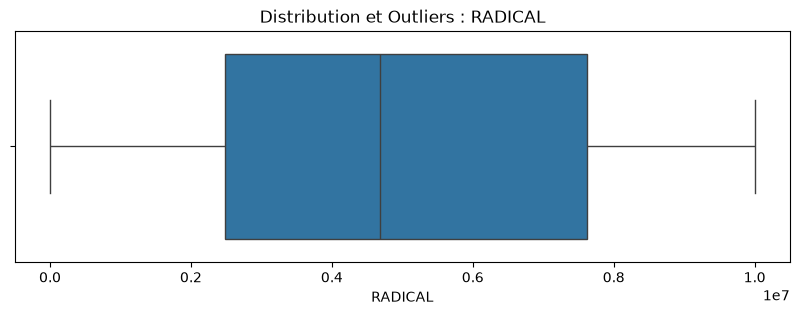

Extraction des données pour : BANQUE...
int64
count    4141.000000
mean       53.909925
std        24.681661
min         1.000000
25%        45.000000
50%        57.000000
75%        78.000000
max        83.000000
Name: BANQUE, dtype: float64


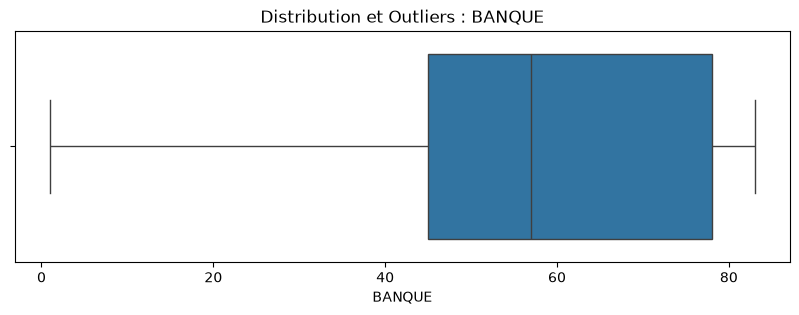

Extraction des données pour : AGENCE...
int64
count    4141.000000
mean       45.716252
std        27.508916
min         1.000000
25%        22.000000
50%        44.000000
75%        68.000000
max        99.000000
Name: AGENCE, dtype: float64


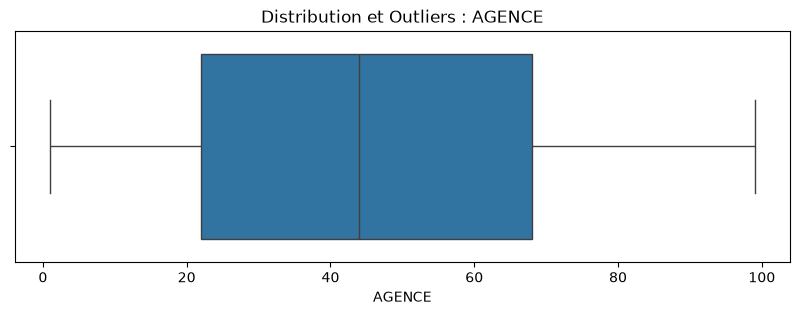

Extraction des données pour : GENERIC...
int64
count     4141.000000
mean     21114.011108
std         13.940986
min      21111.000000
25%      21111.000000
50%      21111.000000
75%      21111.000000
max      21216.000000
Name: GENERIC, dtype: float64


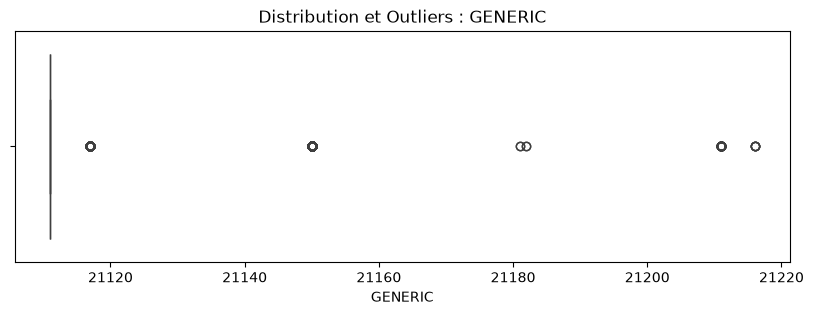

Extraction des données pour : PLURAL...
int64
count    4141.000000
mean        0.812606
std         4.254142
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        95.000000
Name: PLURAL, dtype: float64


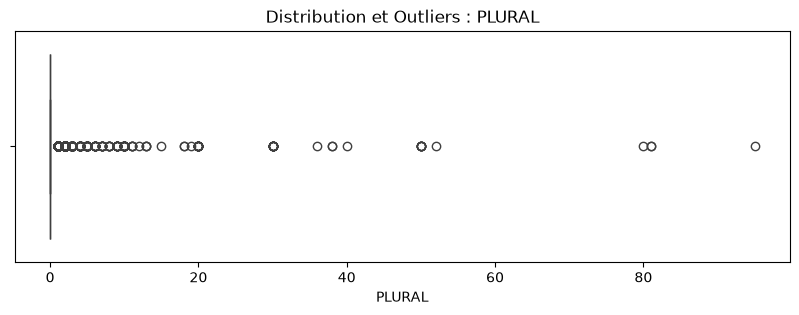

Extraction des données pour : CCLE...
int64
count    4141.000000
mean        4.411012
std         2.896961
min         0.000000
25%         2.000000
50%         4.000000
75%         7.000000
max         9.000000
Name: CCLE, dtype: float64


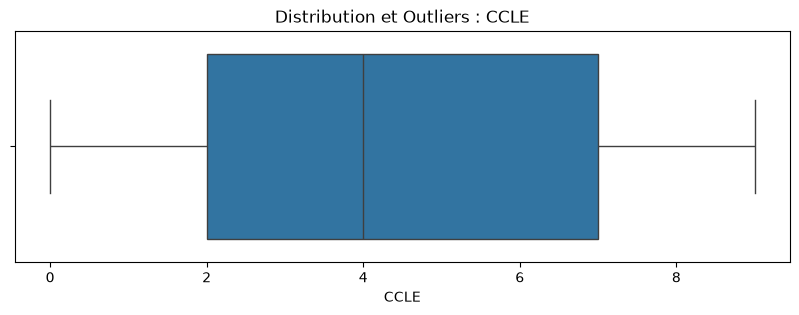

Extraction des données pour : DATE_OF_BIRTH...
float64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: DATE_OF_BIRTH, dtype: float64


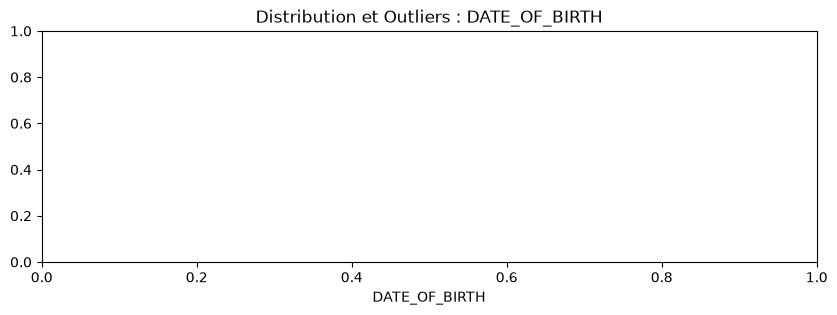

Extraction des données pour : CODE_VILLE...
float64
count    4128.000000
mean      510.089390
std       253.323958
min         0.000000
25%       330.000000
50%       550.000000
75%       780.000000
max       851.000000
Name: CODE_VILLE, dtype: float64


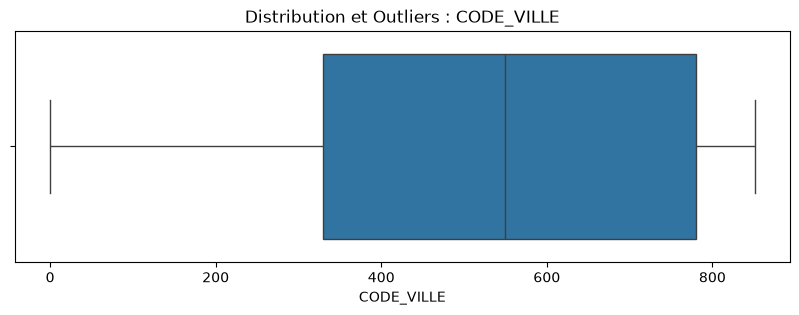

Extraction des données pour : BPR...
int64
count    4141.000000
mean       52.163729
std        25.400012
min         1.000000
25%        27.000000
50%        50.000000
75%        78.000000
max        81.000000
Name: BPR, dtype: float64


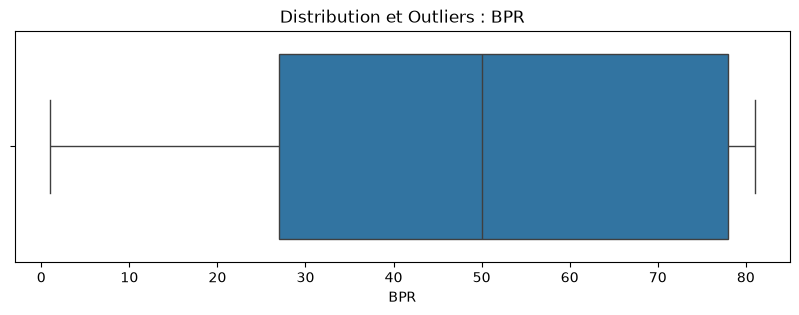

Extraction des données pour : GENDER...
float64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: GENDER, dtype: float64


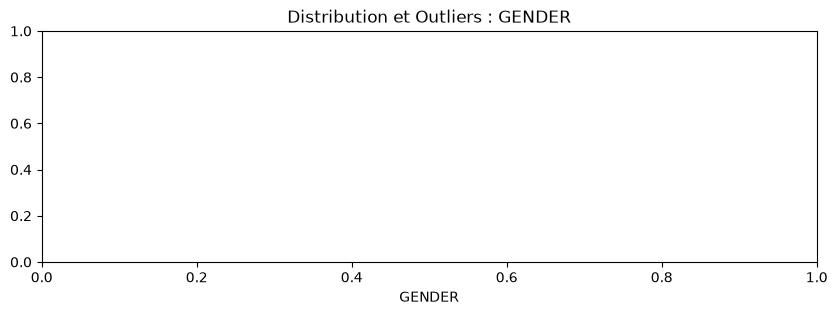

Extraction des données pour : MARITAL_STATUS...
int64
count    4141.000000
mean        2.830476
std         2.332039
min         1.000000
25%         1.000000
50%         3.000000
75%         3.000000
max         9.000000
Name: MARITAL_STATUS, dtype: float64


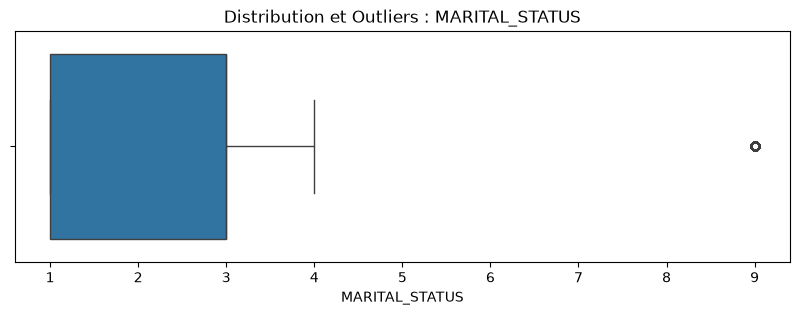

Extraction des données pour : NOMBRE_ENFANT...
int64
count    4141.000000
mean        0.750785
std         1.214725
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        16.000000
Name: NOMBRE_ENFANT, dtype: float64


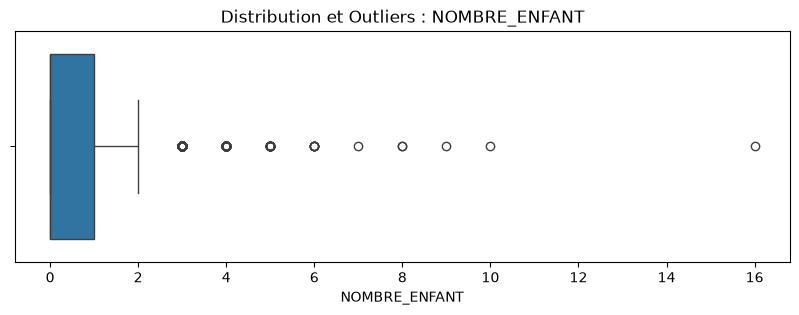

Extraction des données pour : CUSTOMER_RATING...
float64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: CUSTOMER_RATING, dtype: float64


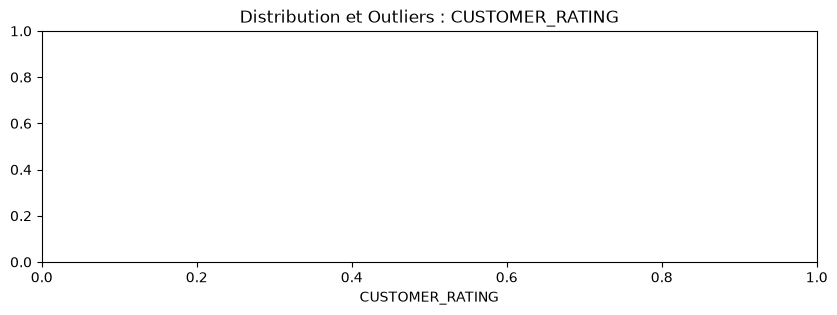

Extraction des données pour : TAILLE_ENTREPRI...
float64
count     4.0
mean     99.0
std       0.0
min      99.0
25%      99.0
50%      99.0
75%      99.0
max      99.0
Name: TAILLE_ENTREPRI, dtype: float64


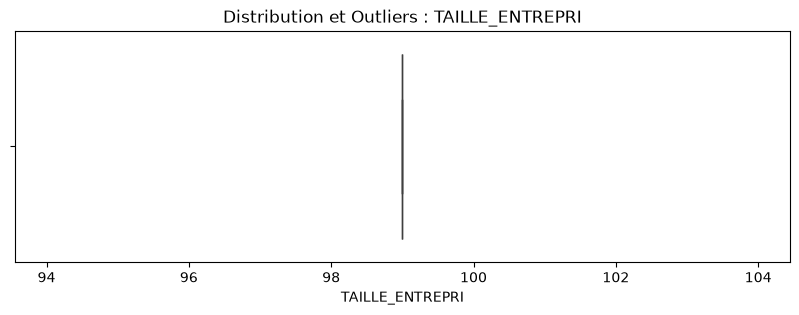

Extraction des données pour : label_code...
int64
count    4141.000000
mean       17.127747
std        16.411506
min         9.000000
25%         9.000000
50%         9.000000
75%         9.000000
max        53.000000
Name: label_code, dtype: float64


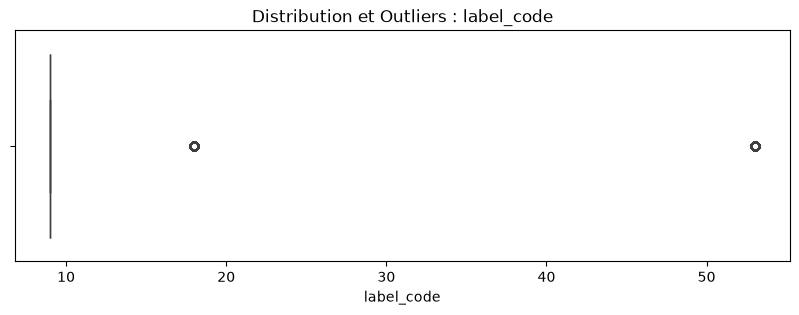

Extraction des données pour : label_nom...
float64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: label_nom, dtype: float64


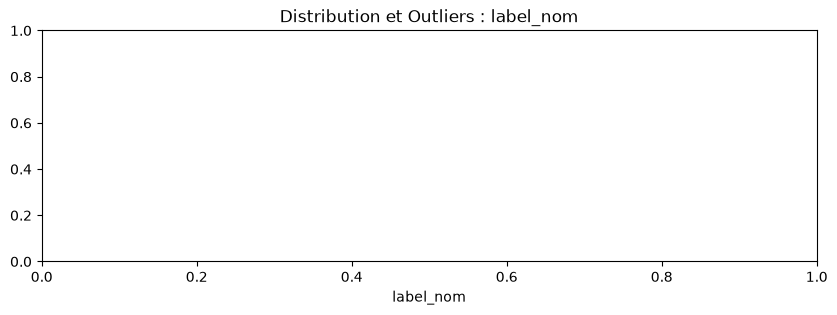

Extraction des données pour : pack_actuel...
float64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: pack_actuel, dtype: float64


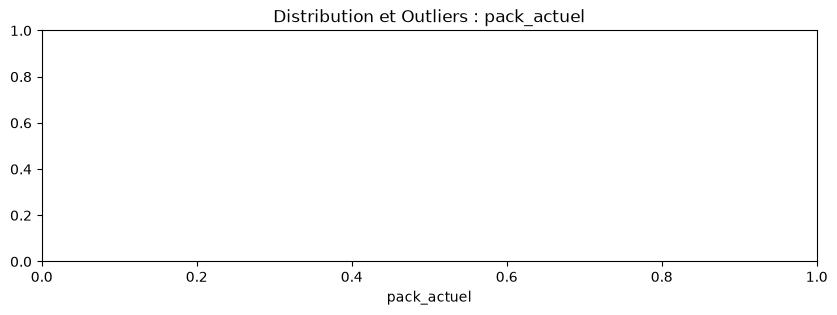

Extraction des données pour : pack_etat...
float64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: pack_etat, dtype: float64


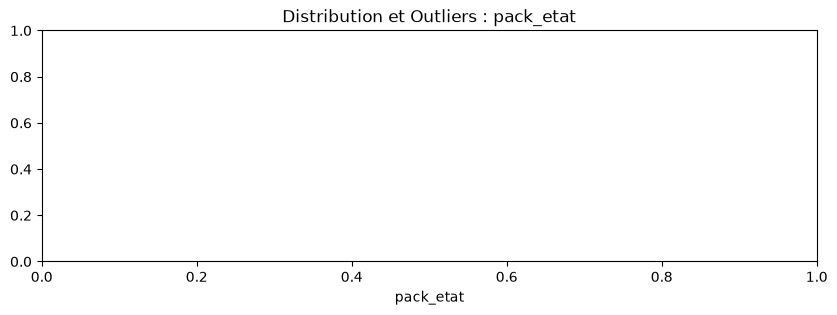

Extraction des données pour : digital_toujours_abonne...
int32
count    4141.000000
mean        0.666023
std         0.471689
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: digital_toujours_abonne, dtype: float64


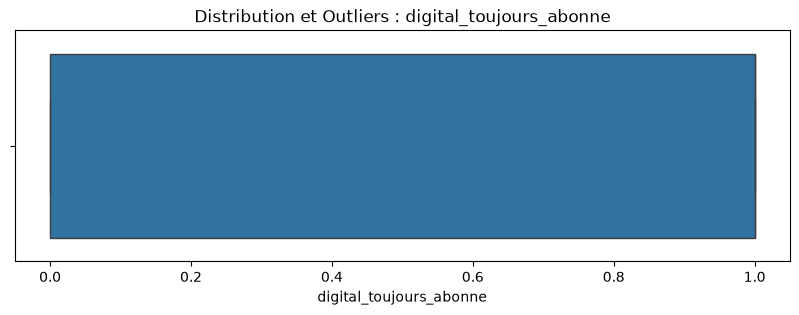

Extraction des données pour : solde_moyen...
float64
count     4141.000000
mean     20973.202492
std      29052.848807
min     -47414.335625
25%        187.750000
50%       6304.682708
75%      33629.122917
max      79296.349375
Name: solde_moyen, dtype: float64


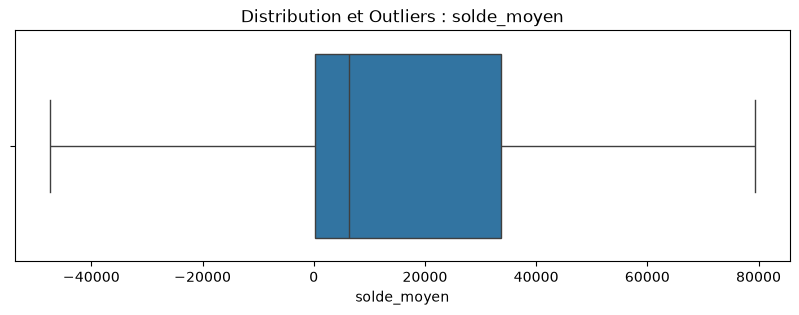

Extraction des données pour : solde_min...
float64
count    4141.000000
mean       61.986197
std      2507.214013
min     -4270.190000
25%     -1029.270000
50%         0.000000
75%      1060.270000
max      4078.610000
Name: solde_min, dtype: float64


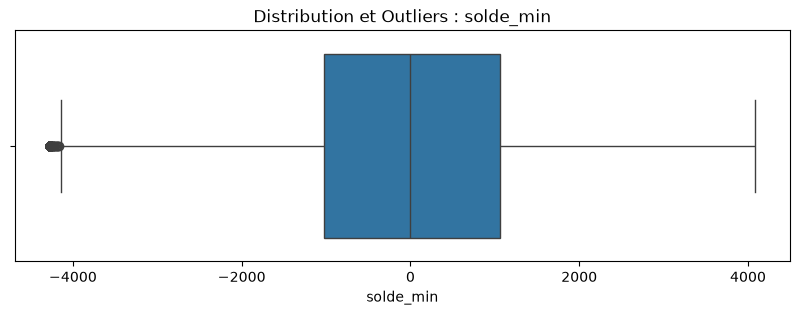

Extraction des données pour : solde_max...
float64
count      4141.000000
mean      80216.059911
std      101968.892169
min      -80569.920000
25%        3195.950000
50%       29349.740000
75%      123910.340000
max      291488.425000
Name: solde_max, dtype: float64


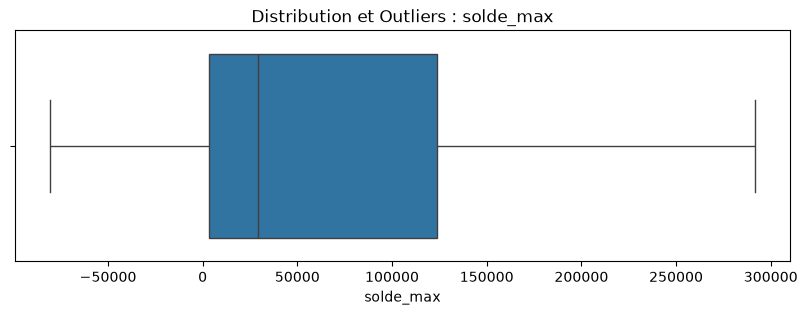

Extraction des données pour : nb_mois_observes_solde...
int64
count    4141.000000
mean       28.645738
std        13.117081
min         1.000000
25%        24.000000
50%        24.000000
75%        24.000000
max       144.000000
Name: nb_mois_observes_solde, dtype: float64


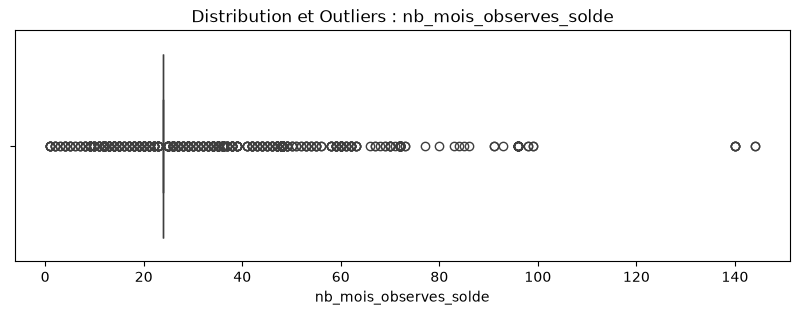

Extraction des données pour : depot_moyen...
float64
count      4141.000000
mean      46432.427621
std       62232.869053
min           0.000000
25%        1001.295106
50%       12469.181200
75%       72088.485417
max      169849.802429
Name: depot_moyen, dtype: float64


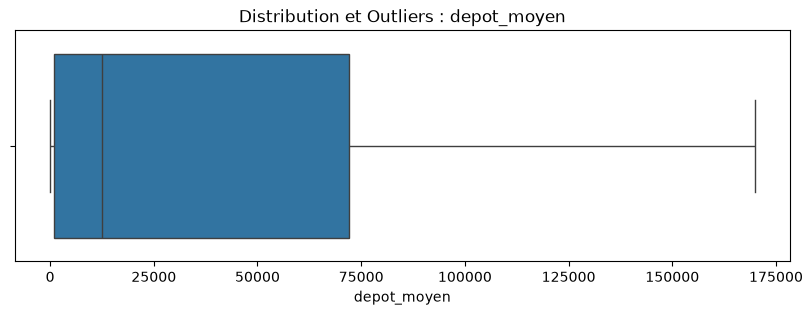

Extraction des données pour : flux_cred_moyen...
float64
count     4141.000000
mean     13083.573389
std      15375.302512
min          0.000000
25%        698.373077
50%       6429.110769
75%      19543.796923
max      45750.994231
Name: flux_cred_moyen, dtype: float64


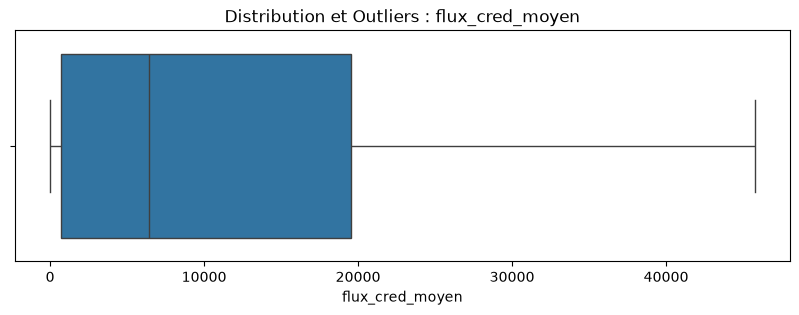

Extraction des données pour : flux_cred_total...
float64
count      4141.000000
mean     205531.156391
std      246027.757493
min           0.000000
25%        9500.000000
50%       97043.180000
75%      308262.770000
max      719364.675000
Name: flux_cred_total, dtype: float64


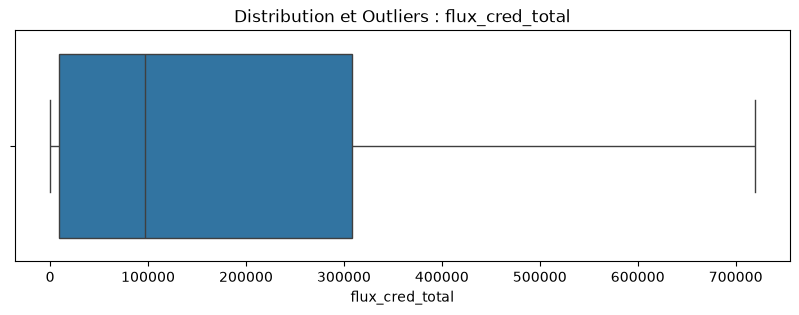

Extraction des données pour : nb_mois_avec_flux...
int64
count    4141.000000
mean        9.324318
std         6.211440
min         0.000000
25%         3.000000
50%        13.000000
75%        13.000000
max        32.000000
Name: nb_mois_avec_flux, dtype: float64


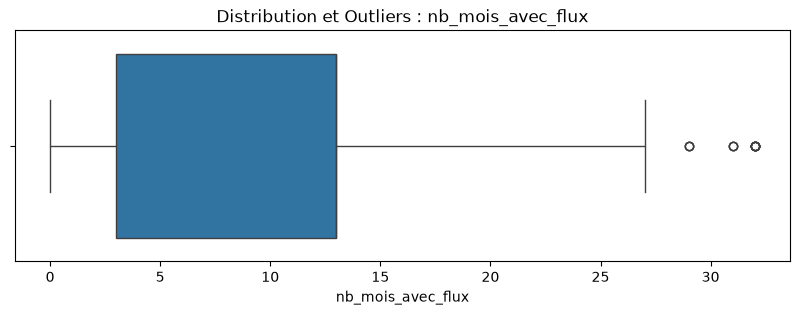

Extraction des données pour : nb_operations_gab...
int64
count    4141.000000
mean       22.348225
std        59.190118
min         0.000000
25%         0.000000
50%         1.000000
75%        16.000000
max      1623.000000
Name: nb_operations_gab, dtype: float64


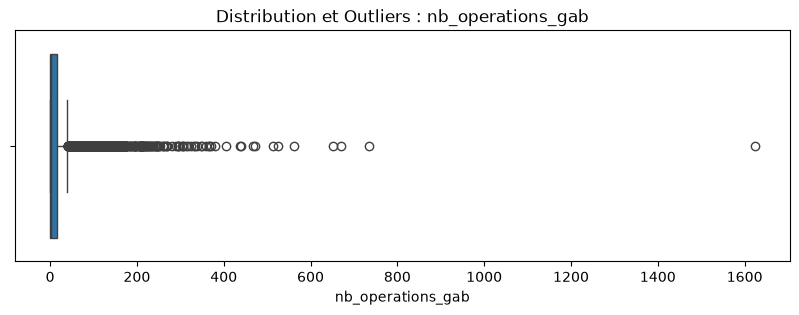

Extraction des données pour : montant_total_gab...
float64
count    4141.000000
mean       76.851321
std       397.260604
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      3456.750000
Name: montant_total_gab, dtype: float64


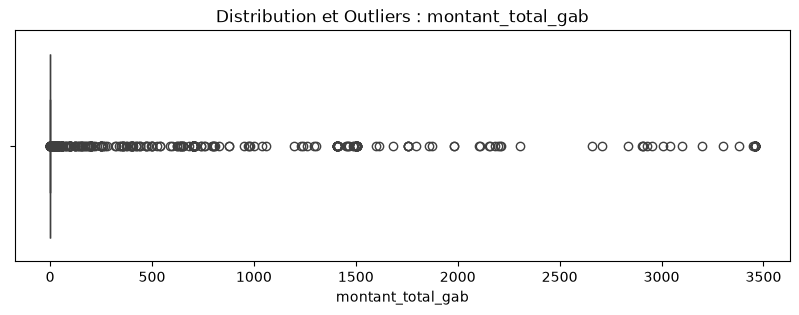

Extraction des données pour : montant_moyen_gab...
float64
count    4141.000000
mean        3.920030
std        21.959528
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       159.729478
Name: montant_moyen_gab, dtype: float64


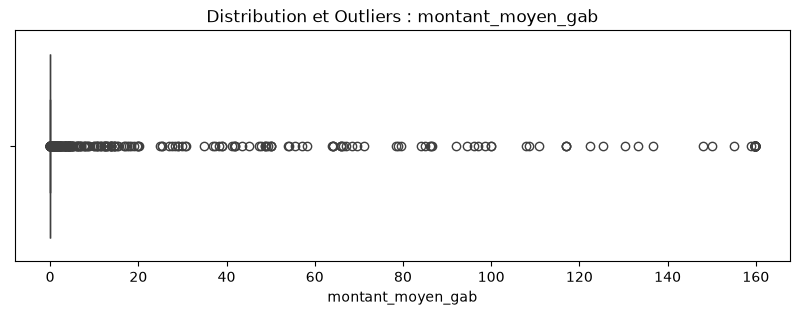

Extraction des données pour : nb_retraits...
int64
count    4141.000000
mean       39.779039
std        54.364335
min         0.000000
25%         0.000000
50%        19.000000
75%        63.000000
max       725.000000
Name: nb_retraits, dtype: float64


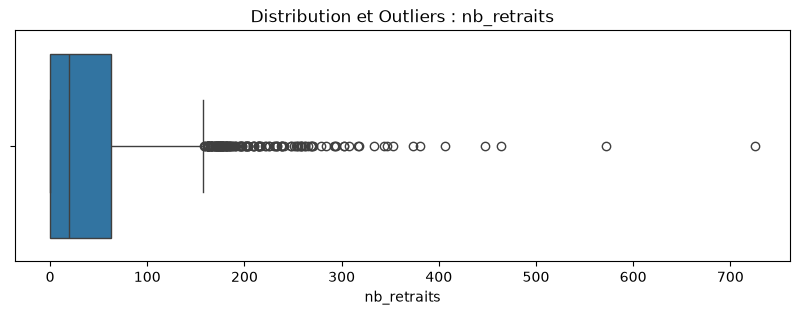

Extraction des données pour : montant_total_retraits...
float64
count      4141.000000
mean      39199.178942
std       47141.838852
min           0.000000
25%           0.000000
50%       19300.000000
75%       65300.000000
max      157000.000000
Name: montant_total_retraits, dtype: float64


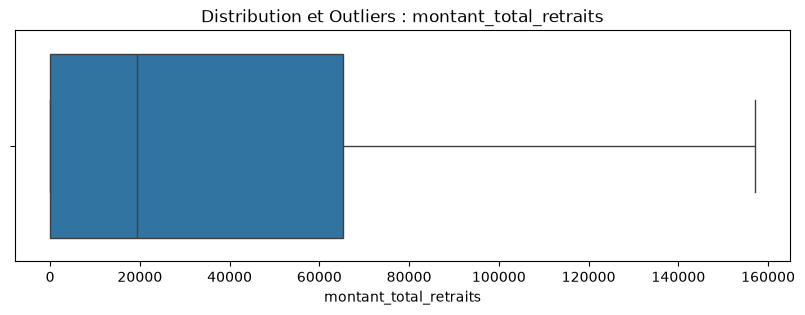

Extraction des données pour : nb_paiements_digitaux...
int64
count    4141.000000
mean       28.866699
std        64.898472
min         0.000000
25%         0.000000
50%         0.000000
75%        21.000000
max       744.000000
Name: nb_paiements_digitaux, dtype: float64


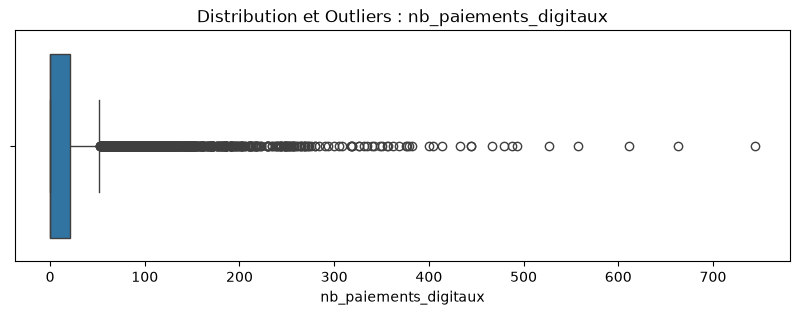

Extraction des données pour : montant_total_payfac...
float64
count     4141.000000
mean      4282.718322
std       9981.765868
min          0.000000
25%          0.000000
50%          0.000000
75%       1990.000000
max      43440.430000
Name: montant_total_payfac, dtype: float64


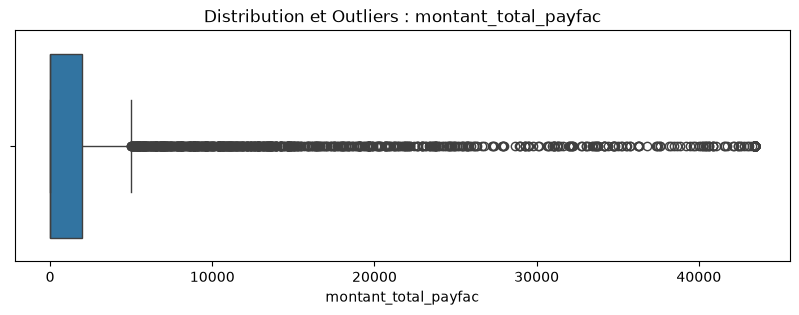

Extraction des données pour : nb_vignettes_payees...
int64
count    4141.000000
mean        0.397730
std         1.611248
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        63.000000
Name: nb_vignettes_payees, dtype: float64


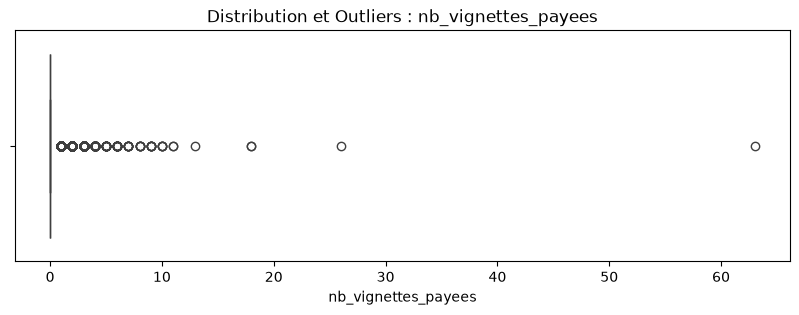

Extraction des données pour : montant_total_vignette...
float64
count    4141.000000
mean      243.045883
std       835.009754
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      5950.000000
Name: montant_total_vignette, dtype: float64


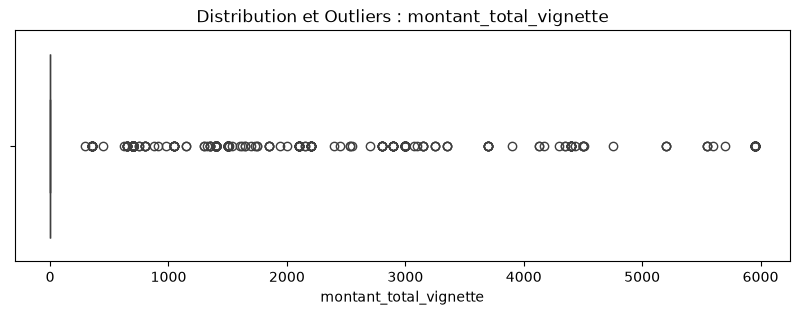

Extraction des données pour : jamais_active_digital...
int32
count    4141.000000
mean        0.334219
std         0.471774
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: jamais_active_digital, dtype: float64


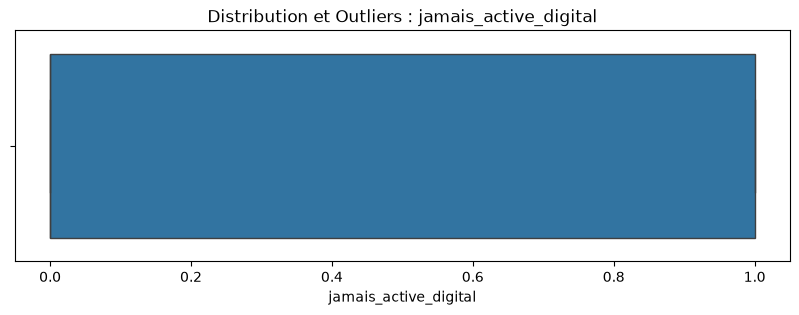

Extraction des données pour : jamais_utilise_gab...
int32
count    4141.000000
mean        0.470418
std         0.499184
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: jamais_utilise_gab, dtype: float64


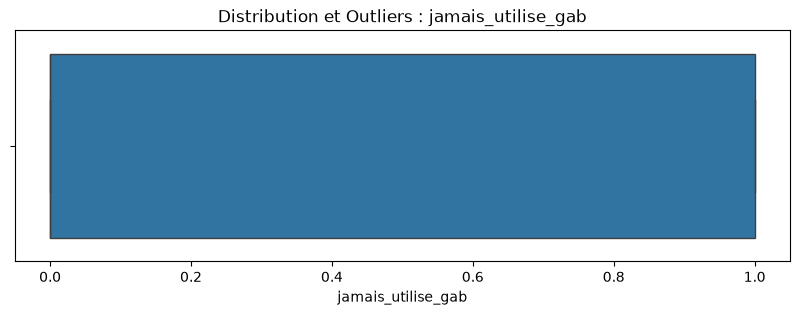

Extraction des données pour : anciennete_digitale_jours_imp...
int32
count    4141.000000
mean     4093.579087
std      1636.764028
min       229.000000
25%      3283.000000
50%      4097.000000
75%      4921.000000
max      9162.000000
Name: anciennete_digitale_jours_imp, dtype: float64


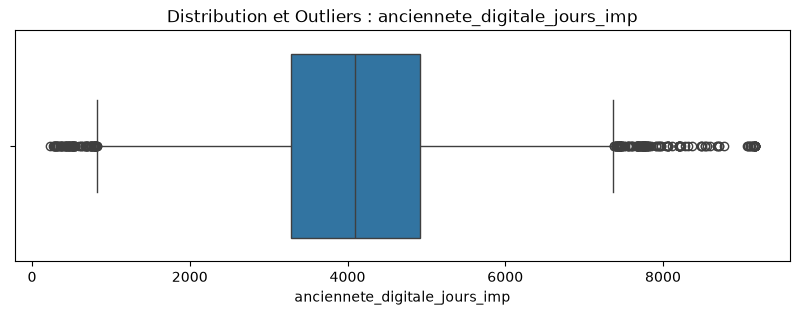

Extraction des données pour : recence_gab_jours_imp...
int32
count    4141.000000
mean      958.314417
std       146.696103
min       647.000000
25%       924.000000
50%       952.000000
75%       970.000000
max      1345.000000
Name: recence_gab_jours_imp, dtype: float64


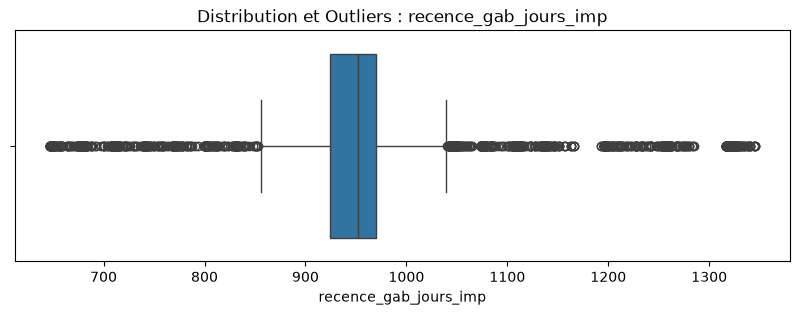

Extraction des données pour : solde_moyen_etait_extreme...
int32
count    4141.000000
mean        0.139097
std         0.346089
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: solde_moyen_etait_extreme, dtype: float64


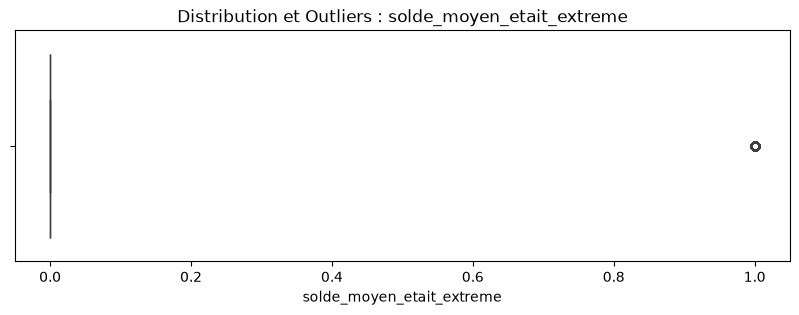

Extraction des données pour : solde_min_etait_extreme...
int32
count    4141.000000
mean        0.275779
std         0.446960
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: solde_min_etait_extreme, dtype: float64


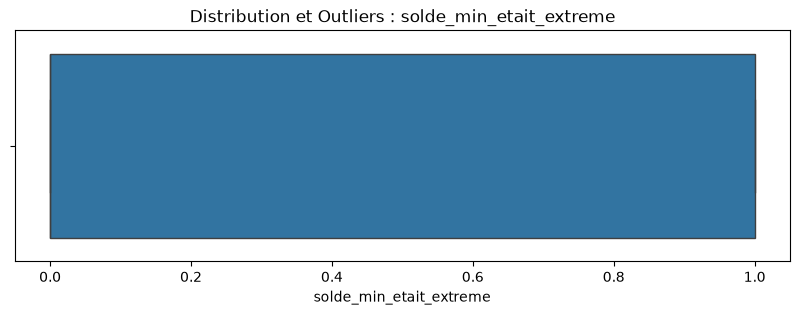

Extraction des données pour : solde_max_etait_extreme...
int32
count    4141.000000
mean        0.125091
std         0.330862
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: solde_max_etait_extreme, dtype: float64


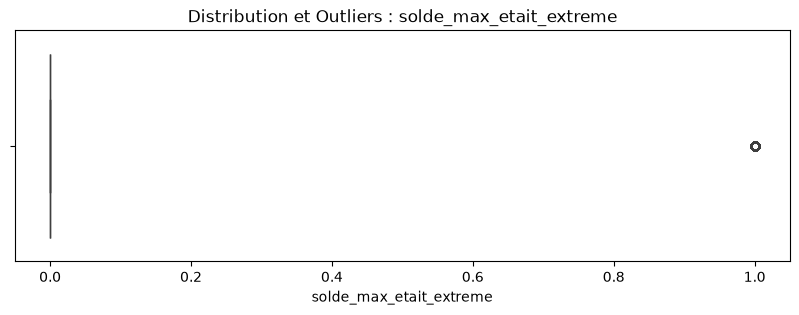

Extraction des données pour : depot_moyen_etait_extreme...
int32
count    4141.000000
mean        0.145376
std         0.352522
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: depot_moyen_etait_extreme, dtype: float64


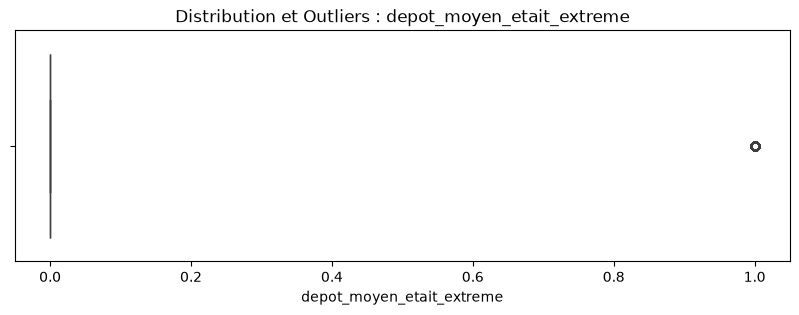

Extraction des données pour : flux_cred_moyen_etait_extreme...
int32
count    4141.000000
mean        0.113258
std         0.316946
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: flux_cred_moyen_etait_extreme, dtype: float64


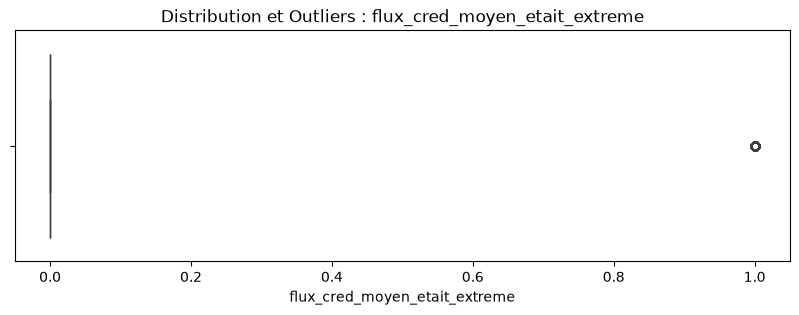

Extraction des données pour : flux_cred_total_etait_extreme...
int32
count    4141.000000
mean        0.122434
std         0.327826
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: flux_cred_total_etait_extreme, dtype: float64


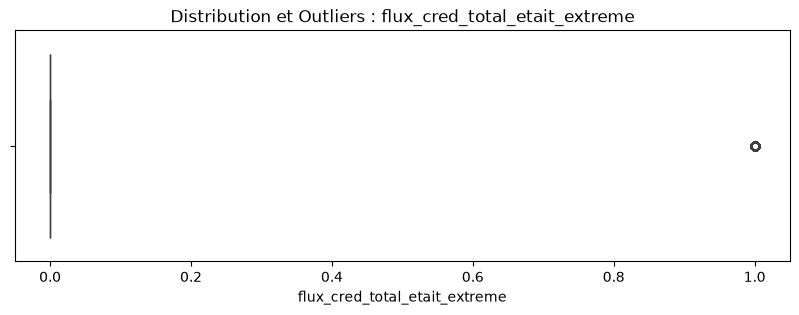

Extraction des données pour : montant_total_gab_etait_extreme...
int32
count    4141.000000
mean        0.006520
std         0.080494
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: montant_total_gab_etait_extreme, dtype: float64


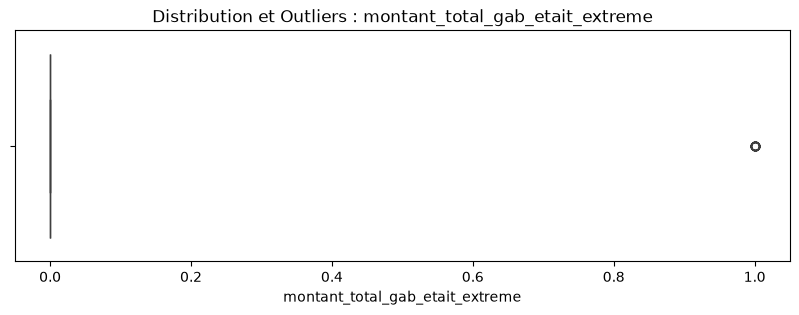

Extraction des données pour : montant_moyen_gab_etait_extreme...
int32
count    4141.000000
mean        0.014731
std         0.120488
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: montant_moyen_gab_etait_extreme, dtype: float64


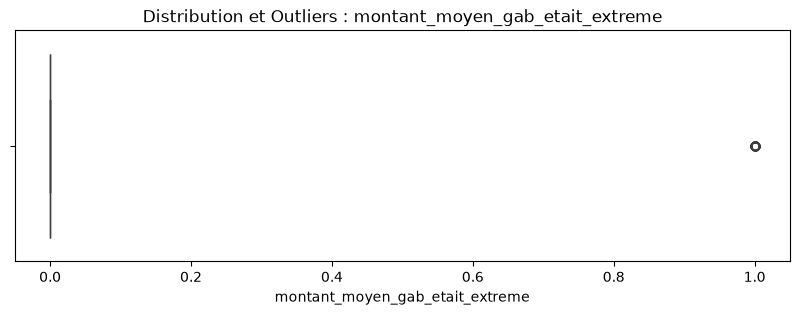

Extraction des données pour : montant_total_retraits_etait_extreme...
int32
count    4141.000000
mean        0.047815
std         0.213399
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: montant_total_retraits_etait_extreme, dtype: float64


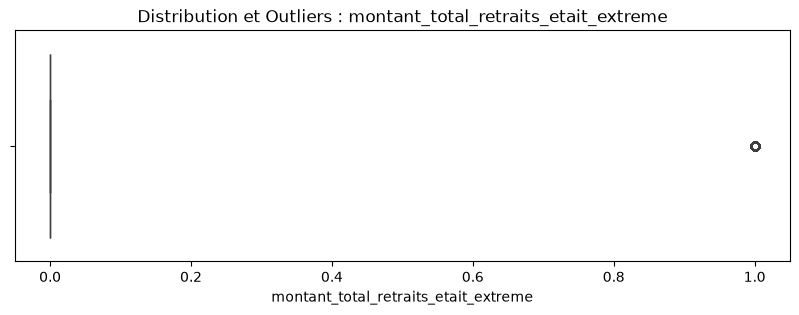

Extraction des données pour : montant_total_payfac_etait_extreme...
int32
count    4141.000000
mean        0.028254
std         0.165718
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: montant_total_payfac_etait_extreme, dtype: float64


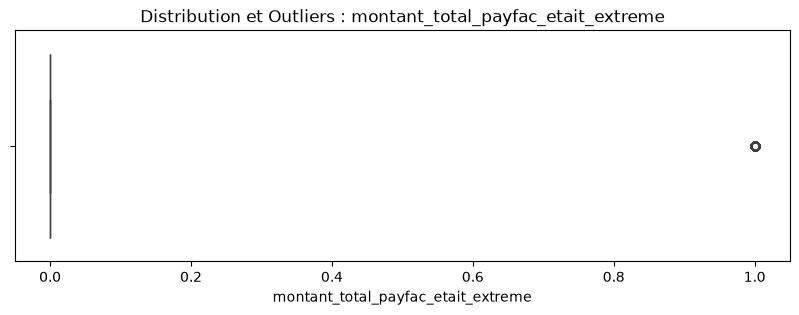

Extraction des données pour : montant_total_vignette_etait_extreme...
int32
count    4141.000000
mean        0.007486
std         0.086208
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: montant_total_vignette_etait_extreme, dtype: float64


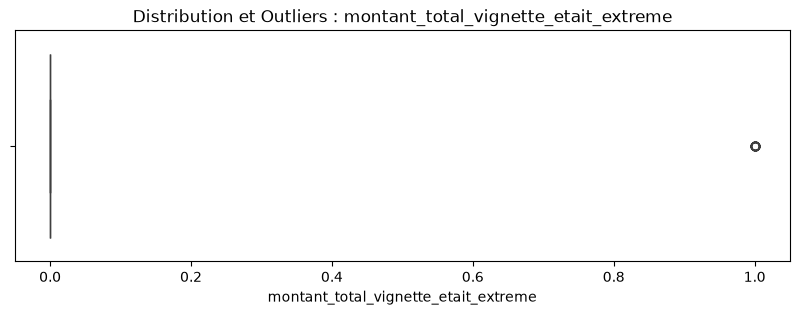

In [26]:
for col in df.columns:
    plot_boxplot(df, col)